<a href="https://colab.research.google.com/github/IbrahimHanafy2222/Computer-Vision-Project/blob/main/ComputerVisionProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data loading & Preprocessing

Dataset URL: https://www.kaggle.com/datasets/datamunge/sign-language-mnist
License(s): CC0-1.0
100% 62.6M/62.6M [00:00<00:00, 132MB/s]

Download and extraction complete!

Data loaded successfully!
Training set shape: (27455, 785)
Testing set shape: (7172, 785)



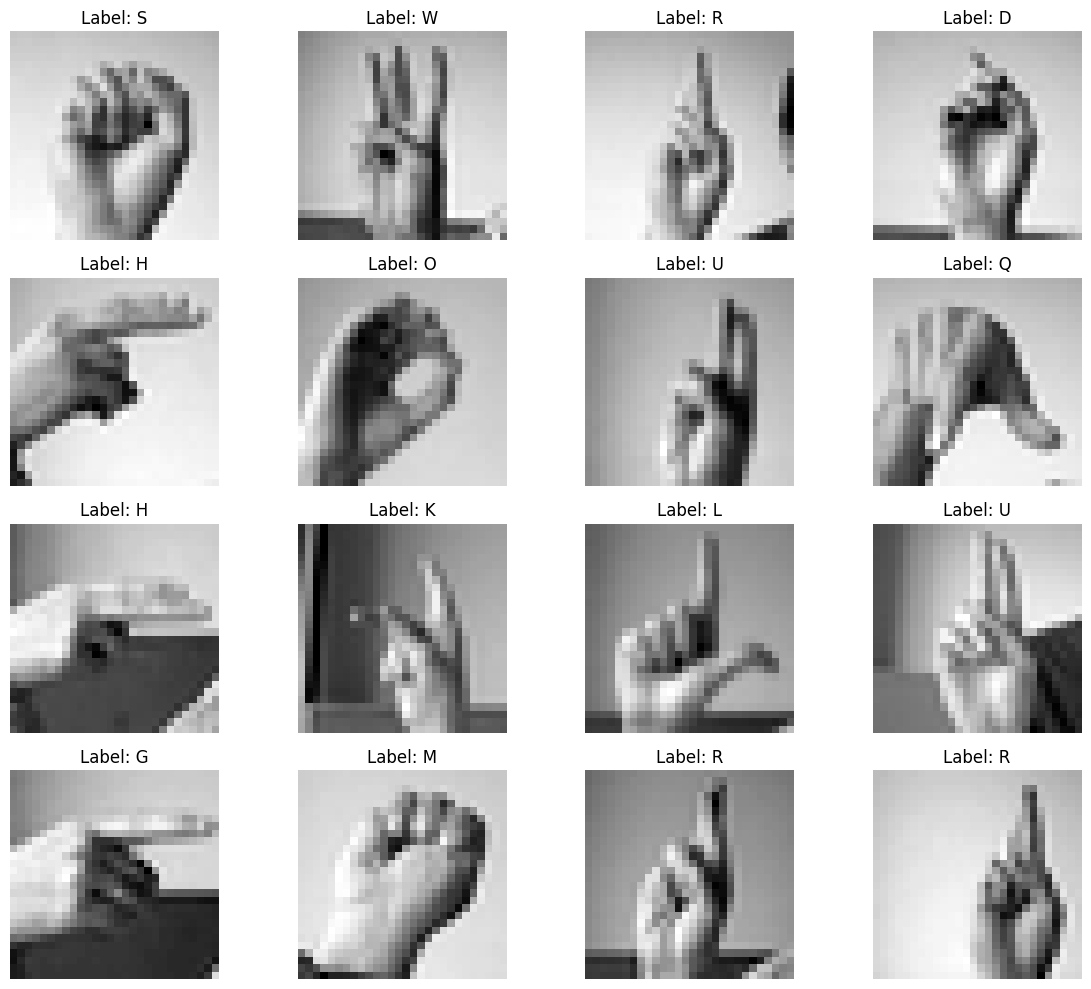

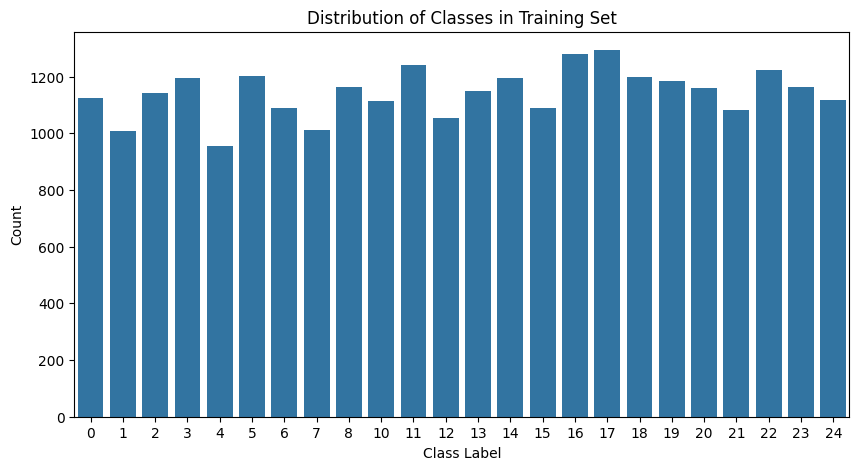

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set your Kaggle API credentials directly
os.environ['KAGGLE_USERNAME'] = "abdullahashiry" # <--- CHANGE THIS
os.environ['KAGGLE_KEY'] = "KGAT_331632d901a6cb7a05431b55135bd8c2"

# 2. Download and unzip the dataset directly from Kaggle
print("Downloading dataset...")
!kaggle datasets download -d datamunge/sign-language-mnist --unzip
print("Download and extraction complete!\n")

# 3. Load the data
train_path = 'sign_mnist_train/sign_mnist_train.csv'
test_path = 'sign_mnist_test/sign_mnist_test.csv'

# Fallback check in case the extraction structure changes
if not os.path.exists(train_path):
    train_path = 'sign_mnist_train.csv'
    test_path = 'sign_mnist_test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Data loaded successfully!")
print(f"Training set shape: {train_df.shape}")
print(f"Testing set shape: {test_df.shape}\n")

# 4. Separate labels and pixel features
y_train = train_df['label'].values
x_train = train_df.drop('label', axis=1).values

y_test = test_df['label'].values
x_test = test_df.drop('label', axis=1).values

# 5. Reshape the 1D arrays (784 pixels) back into 2D images (28x28)
x_train = x_train.reshape(-1, 28, 28)
x_test = x_test.reshape(-1, 28, 28)

# 6. Map the numeric labels to actual alphabet letters
alphabet_mapping = {0:'A', 1:'B', 2:'C', 3:'D', 4:'E', 5:'F', 6:'G', 7:'H', 8:'I',
                    10:'K', 11:'L', 12:'M', 13:'N', 14:'O', 15:'P', 16:'Q', 17:'R',
                    18:'S', 19:'T', 20:'U', 21:'V', 22:'W', 23:'X', 24:'Y'}

# 7. Visualize a random sample of the training data
plt.figure(figsize=(12, 10))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    idx = np.random.randint(0, len(x_train))
    plt.imshow(x_train[idx], cmap='gray')

    letter = alphabet_mapping[y_train[idx]]
    plt.title(f"Label: {letter}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# 8. Check the class distribution
plt.figure(figsize=(10, 5))
sns.countplot(x=y_train)
plt.title("Distribution of Classes in Training Set")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.show()

# Classical Pipeline

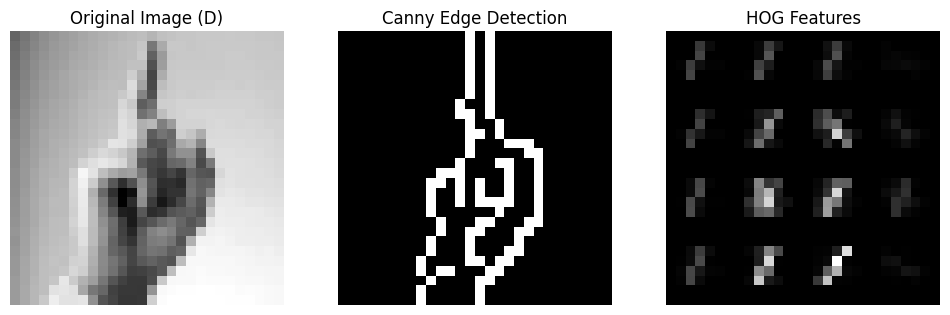

Extracting features from Training Data... (This may take a minute)
Done! Extracted 325 features per image in 81.16 seconds.
Extracting features from Testing Data...

Training the SVM Classifier... (This will take a few minutes)
Training completed in 14.78 seconds.

Evaluating the model on the test set...
Test Accuracy: 97.09%

Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       331
           B       1.00      0.97      0.99       432
           C       1.00      0.93      0.96       310
           D       1.00      1.00      1.00       245
           E       0.96      1.00      0.98       498
           F       1.00      1.00      1.00       247
           G       1.00      0.94      0.97       348
           H       1.00      1.00      1.00       436
           I       1.00      1.00      1.00       288
           K       1.00      1.00      1.00       331
           L       1.00

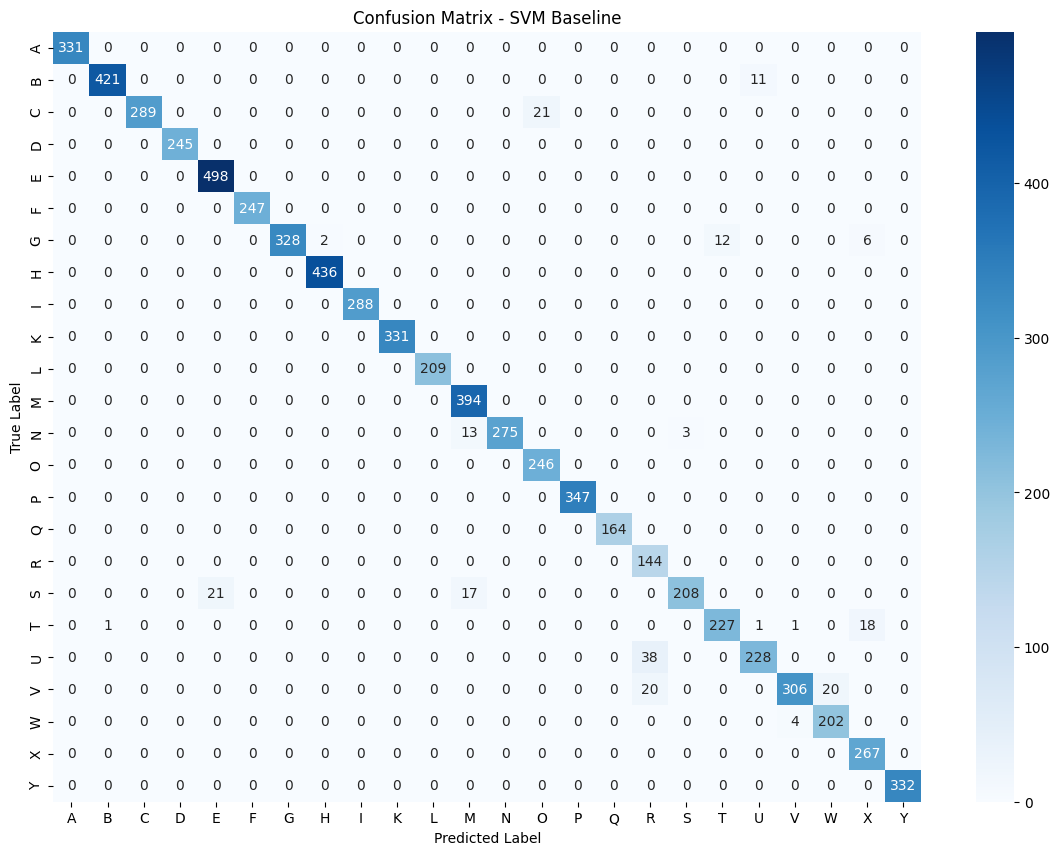

In [ ]:
import cv2
import numpy as np
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

# ==========================================
# 1. THE MODULAR PREPROCESSING FUNCTION
# (We will reuse this for deployment later)
# ==========================================
def extract_features(image_2d, visualize=False):
    """
    Takes a 28x28 grayscale image, applies edge detection, and extracts HOG features.
    """
    # Ensure image is 8-bit unsigned integer (required by OpenCV)
    img_uint8 = image_2d.astype(np.uint8)

    # Preprocessing: Slight Gaussian Blur to reduce noise before edge detection
    blurred = cv2.GaussianBlur(img_uint8, (3, 3), 0)

    # Edge Detection: Canny Edge Detector
    edges = cv2.Canny(blurred, threshold1=50, threshold2=150)

    # Feature Extraction: HOG (Histogram of Oriented Gradients)
    # HOG is excellent at capturing the shape and structure of hands
    features, hog_img = hog(blurred, orientations=9,
                            pixels_per_cell=(7, 7),
                            cells_per_block=(2, 2),
                            visualize=True,
                            block_norm='L2-Hys')

    # We combine the HOG features with a simple edge density feature
    # (percentage of pixels that are edges) to ensure both techniques are utilized.
    edge_density = np.sum(edges) / (255.0 * 28 * 28)
    final_feature_vector = np.append(features, edge_density)

    if visualize:
        return final_feature_vector, edges, hog_img
    return final_feature_vector

# ==========================================
# 2. VISUALIZE THE PIPELINE
# ==========================================
# Let's grab one image to see what the computer actually "sees"
sample_idx = 0
sample_img = x_train[sample_idx]
sample_label = alphabet_mapping[y_train[sample_idx]]

_, edges_img, hog_img = extract_features(sample_img, visualize=True)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
ax1.imshow(sample_img, cmap='gray')
ax1.set_title(f'Original Image ({sample_label})')
ax1.axis('off')

ax2.imshow(edges_img, cmap='gray')
ax2.set_title('Canny Edge Detection')
ax2.axis('off')

ax3.imshow(hog_img, cmap='gray')
ax3.set_title('HOG Features')
ax3.axis('off')
plt.show()

# ==========================================
# 3. PROCESS THE ENTIRE DATASET
# ==========================================
print("Extracting features from Training Data... (This may take a minute)")
start_time = time.time()
x_train_features = np.array([extract_features(img) for img in x_train])
print(f"Done! Extracted {x_train_features.shape[1]} features per image in {time.time() - start_time:.2f} seconds.")

print("Extracting features from Testing Data...")
x_test_features = np.array([extract_features(img) for img in x_test])

# ==========================================
# 4. TRAIN THE SVM CLASSIFIER
# ==========================================
print("\nTraining the SVM Classifier... (This will take a few minutes)")
start_time = time.time()
# We use an RBF kernel as it generally performs best for complex image boundaries
svm_model = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_model.fit(x_train_features, y_train)
print(f"Training completed in {time.time() - start_time:.2f} seconds.")

# ==========================================
# 5. EVALUATE THE MODEL
# ==========================================
print("\nEvaluating the model on the test set...")
y_pred = svm_model.predict(x_test_features)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy * 100:.2f}%\n")

# Precision and Recall (Classification Report)
print("Classification Report (Precision, Recall, F1-Score):")
# We filter out J(9) and Z(25) from the target names
target_names = [alphabet_mapping[i] for i in sorted(list(set(y_test)))]
print(classification_report(y_test, y_pred, target_names=target_names))

# Confusion Matrix
plt.figure(figsize=(14, 10))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - SVM Baseline')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Custom CNN

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 899,737 (3.43 MB)

 Trainable params: 899,289 (3.43 MB)

 Non-trainable params: 448 (1.75 KB)


Training the Custom CNN...
Epoch 1/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.3924 - loss: 1.8835 - val_accuracy: 0.2440 - val_loss: 2.3168
Epoch 2/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6643 - loss: 0.9106 - val_accuracy: 0.9851 - val_loss: 0.2063
Epoch 3/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7301 - loss: 0.7066 - val_accuracy: 0.9945 - val_loss: 0.0715
Epoch 4/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7558 - loss: 0.6166 - val_accuracy: 0.9989 - val_loss: 0.0385
Epoch 5/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7877 - loss: 0.5398 - val_accuracy: 0.9989 - val_loss: 0.0203
Epoch 6/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8035 - loss: 0.4985 - val_accuracy: 0.8989 - val_loss: 0.2766
Epoch 7/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8216 - loss: 0.4568 - val_accuracy: 0.9805 - val_loss: 0.0654
Epoch 8/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8272 - l

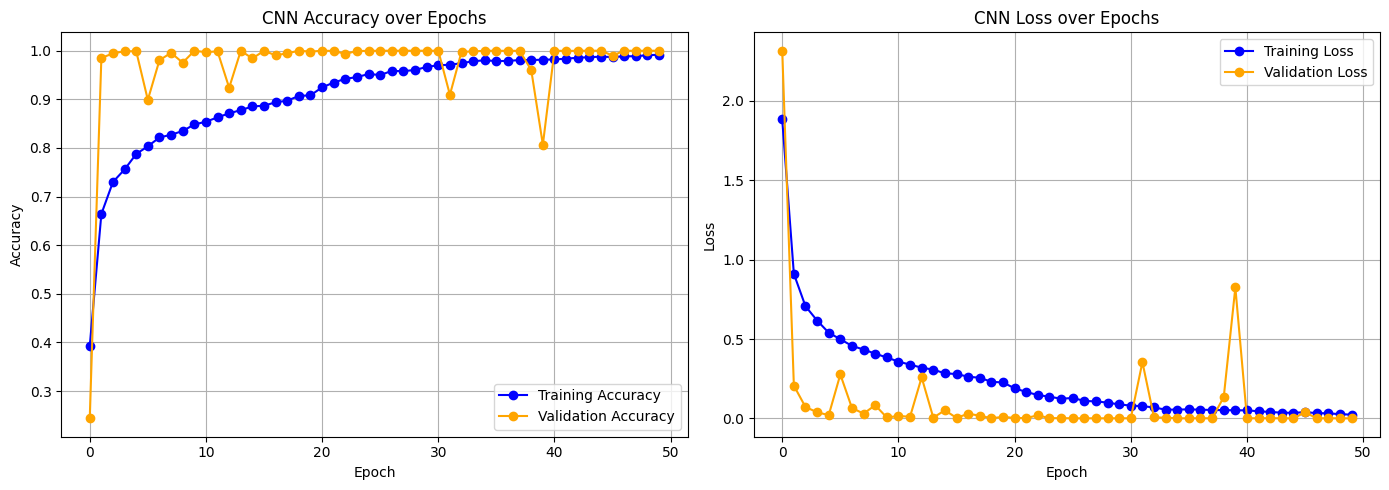

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# ==========================================
# 1. PREPARE DATA FOR THE CNN
# ==========================================
# CNNs expect images to have a "color channel" dimension.
# We need to reshape from (28, 28) to (28, 28, 1) for grayscale.
x_train_cnn = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test_cnn = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# The labels go up to 24 (with J=9 missing), so we need 25 output neurons.
num_classes = 25

# ==========================================
# 2. DESIGN THE CUSTOM CNN ARCHITECTURE
# ==========================================
# Justification for Paper: We use two convolutional blocks to extract spatial
# hierarchies (edges, then shapes). We use MaxPooling to reduce dimensions
# and Dropout to heavily penalize overfitting.
model = models.Sequential([
    # Block 1: Feature Extraction
    layers.Conv2D(32, (3, 3), input_shape=(28, 28, 1), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.1),

    # Block 2: Deeper Feature Extraction
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # Block 3
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.25),

    # Flatten the 2D feature maps into a 1D array for the dense layers
    layers.Flatten(),

    # Block 3: Classification Network with Dropout for Regularization
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Drops 50% of neurons randomly to prevent overfitting

    # Output Layer: 25 neurons for our classes, softmax for probabilities
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# ==========================================
# 3. TRAIN THE MODEL FROM SCRATCH
# ==========================================
print("\nTraining the Custom CNN...")
# We use a 20% validation split directly during training to plot our curves
history = model.fit(x_train_cnn, y_train,
                    epochs=50,
                    batch_size=64,
                    validation_split=0.2)

# ==========================================
# 4. EVALUATE ON TEST SET
# ==========================================
test_loss, test_acc = model.evaluate(x_test_cnn, y_test, verbose=2)
print(f"\nFinal CNN Test Accuracy: {test_acc * 100:.2f}%")

# ==========================================
# 5. PLOT TRAINING & VALIDATION CURVES
# ==========================================
# This fulfills the explicit requirement to plot curves and analyze overfitting
plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='o')
plt.title('CNN Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', marker='o')
plt.title('CNN Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Data Augmentation & LR Scheduling

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint

# ==========================================
# 1. EXPLICITLY SPLIT THE DATA
# ==========================================
# We split 20% of the training data off to act as our validation set
x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
    x_train_cnn, y_train, test_size=0.2, random_state=42
)

# ==========================================
# 2. SET UP DATA AUGMENTATION
# ==========================================
# We keep the augmentations relatively mild. If we rotate too much,
# a sign language gesture might look like a completely different letter!
datagen = ImageDataGenerator(
    rotation_range=10,      # Randomly rotate by up to 10 degrees
    zoom_range=0.1,         # Randomly zoom in/out by 10%
    width_shift_range=0.1,  # Randomly shift left/right by 10%
    height_shift_range=0.1  # Randomly shift up/down by 10%
)
datagen.fit(x_train_split)

# ==========================================
# 3. SET UP ADVANCED CALLBACKS
# ==========================================
# Callback 1: Save the absolute best weights
checkpoint_callback = ModelCheckpoint(
    filepath='best_augmented_cnn.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Callback 2: Learning Rate Scheduler
# If the validation accuracy doesn't improve for 3 epochs, cut the learning rate in half.
lr_reduction = ReduceLROnPlateau(
    monitor='val_accuracy',
    patience=3,
    verbose=1,
    factor=0.5,
    min_lr=0.00001
)

# ==========================================
# 4. TRAIN THE AUGMENTED MODEL
# ==========================================
print("\nTraining the Custom CNN with Data Augmentation...")
history = model.fit(
    datagen.flow(x_train_split, y_train_split, batch_size=64),
    epochs=50,
    validation_data=(x_val_split, y_val_split), # Explicitly pass the validation set
    callbacks=[checkpoint_callback, lr_reduction]
)

# Load the best weights and evaluate on the unseen test set
model.load_weights('best_augmented_cnn.h5')
test_loss, test_acc = model.evaluate(x_test_cnn, y_test, verbose=2)
print(f"\nFinal Augmented CNN Test Accuracy: {test_acc * 100:.2f}%")


Training the Custom CNN with Data Augmentation...
Epoch 1/50
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8282 - loss: 0.7175
Epoch 1: val_accuracy improved from None to 0.99545, saving model to best_augmented_cnn.h5



Epoch 1: finished saving model to best_augmented_cnn.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.8626 - loss: 0.4895 - val_accuracy: 0.9954 - val_loss: 0.0168 - learning_rate: 0.0010
Epoch 2/50
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9149 - loss: 0.2701
Epoch 2: val_accuracy improved from 0.99545 to 0.99818, saving model to best_augmented_cnn.h5



Epoch 2: finished saving model to best_augmented_cnn.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9245 - loss: 0.2363 - val_accuracy: 0.9982 - val_loss: 0.0065 - learning_rate: 0.0010
Epoch 3/50
342/344 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9382 - loss: 0.1954
Epoch 3: val_accuracy improved from 0.99818 to 1.00000, saving model to best_augmented_cnn.h5



Epoch 3: finished saving model to best_augmented_cnn.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9434 - loss: 0.1789 - val_accuracy: 1.0000 - val_loss: 4.0519e-04 - learning_rate: 0.0010
Epoch 4/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9582 - loss: 0.1342
Epoch 4: val_accuracy did not improve from 1.00000
344/344 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9585 - loss: 0.1284 - val_accuracy: 0.9880 - val_loss: 0.0308 - learning_rate: 0.0010
Epoch 5/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9599 - loss: 0.1284
Epoch 5: val_accuracy did not improve from 1.00000
344/344 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9638 - loss: 0.1187 - val_accuracy: 0.9973 - val_loss: 0.0089 - learning_rate: 0.0010
Epoch 6/50
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9664 - loss: 0.1073
Epoch 6: val_accuracy did not improve from 1.00000

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
344/344 ━━━━━━━━━━━━━━

# Transfer Learning

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

# ==========================================
# 1. PREPARE THE DATA
# ==========================================
# We start with the basic 28x28x1 grayscale shapes
x_train_tl = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test_tl = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# Split for validation (reusing the split method from Phase 4)
from sklearn.model_selection import train_test_split
x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
    x_train_tl, y_train, test_size=0.2, random_state=42
)

# ==========================================
# 2. LOAD THE PRE-TRAINED BASE MODEL
# ==========================================
# We load MobileNetV2, but we say include_top=False to chop off its original
# 1000-class ImageNet brain. We just want its trained feature-extraction "eyes".
base_model = MobileNetV2(weights='imagenet',
                         include_top=False,
                         input_shape=(96, 96, 3))

# We freeze the base model so we don't destroy its pre-trained weights
# during our initial training phase.
base_model.trainable = False

# ==========================================
# 3. BUILD THE TRANSFER LEARNING PIPELINE
# ==========================================
model_tl = models.Sequential([
    # Input Layer matching our actual data
    layers.InputLayer(input_shape=(28, 28, 1)),

    # Preprocessing Step 1: Convert Grayscale (1 channel) to RGB (3 channels)
    # We do this by repeating the single channel 3 times
    layers.Lambda(lambda x: tf.image.grayscale_to_rgb(x)),

    # Preprocessing Step 2: Resize from 28x28 to 96x96 (Minimum for MobileNet)
    layers.Resizing(96, 96),

    # The Pre-trained MobileNetV2 Feature Extractor
    base_model,

    # Our Custom Classification Head
    layers.GlobalAveragePooling2D(), # A highly efficient flattening alternative
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(25, activation='softmax') # 25 output classes for our sign language
])

model_tl.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

model_tl.summary()

# ==========================================
# 4. TRAIN THE CLASSIFICATION HEAD
# ==========================================
print("\nTraining the Transfer Learning Model (Head Only)...")

# Callbacks to save the best model and manage learning rate
checkpoint_tl = ModelCheckpoint('best_mobilenet_sign_language.h5',
                                monitor='val_accuracy',
                                save_best_only=True,
                                verbose=1)

lr_reduction_tl = ReduceLROnPlateau(monitor='val_accuracy',
                                    patience=2,
                                    factor=0.5,
                                    min_lr=0.00001,
                                    verbose=1)

# We can train for fewer epochs because MobileNet already knows how to "see" edges and shapes
history_tl = model_tl.fit(x_train_split, y_train_split,
                          epochs=15,
                          batch_size=64,
                          validation_data=(x_val_split, y_val_split),
                          callbacks=[checkpoint_tl, lr_reduction_tl])

# ==========================================
# 5. EVALUATE ON TEST SET
# ==========================================
model_tl.load_weights('best_mobilenet_sign_language.h5')
test_loss_tl, test_acc_tl = model_tl.evaluate(x_test_tl, y_test, verbose=2)
print(f"\nFinal Transfer Learning Test Accuracy: {test_acc_tl * 100:.2f}%")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,425,177 (9.25 MB)

...


Epoch 4: finished saving model to best_mobilenet_sign_language.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9770 - loss: 0.0867 - val_accuracy: 0.9980 - val_loss: 0.0167 - learning_rate: 0.0010
Epoch 5/15
341/344 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9811 - loss: 0.0704
Epoch 5: val_accuracy did not improve from 0.99800
344/344 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9817 - loss: 0.0674 - val_accuracy: 0.9980 - val_loss: 0.0128 - learning_rate: 0.0010
Epoch 6/15
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9850 - loss: 0.0590
Epoch 6: val_accuracy improved from 0.99800 to 0.99854, saving model to best_mobilenet_sign_language.h5



Epoch 6: finished saving model to best_mobilenet_sign_language.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9857 - loss: 0.0538 - val_accuracy: 0.9985 - val_loss: 0.0083 - learning_rate: 0.0010
Epoch 7/15
342/344 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9874 - loss: 0.0473
Epoch 7: val_accuracy did not improve from 0.99854
344/344 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9879 - loss: 0.0443 - val_accuracy: 0.9980 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 8/15
340/344 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9890 - loss: 0.0390
Epoch 8: val_accuracy did not improve from 0.99854

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
344/344 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9893 - loss: 0.0379 - val_accuracy: 0.9984 - val_loss: 0.0067 - learning_rate: 0.0010
Epoch 9/15
341/344 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9926 - loss: 0.0264
Epoch 9: val_accuracy improved from 0.99854 to 0.99873, saving mode


Epoch 9: finished saving model to best_mobilenet_sign_language.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9934 - loss: 0.0252 - val_accuracy: 0.9987 - val_loss: 0.0044 - learning_rate: 5.0000e-04
Epoch 10/15
341/344 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9955 - loss: 0.0221
Epoch 10: val_accuracy improved from 0.99873 to 0.99927, saving model to best_mobilenet_sign_language.h5



Epoch 10: finished saving model to best_mobilenet_sign_language.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9946 - loss: 0.0225 - val_accuracy: 0.9993 - val_loss: 0.0038 - learning_rate: 5.0000e-04
Epoch 11/15
340/344 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9944 - loss: 0.0212
Epoch 11: val_accuracy improved from 0.99927 to 0.99982, saving model to best_mobilenet_sign_language.h5



Epoch 11: finished saving model to best_mobilenet_sign_language.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9947 - loss: 0.0207 - val_accuracy: 0.9998 - val_loss: 0.0033 - learning_rate: 5.0000e-04
Epoch 12/15
341/344 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9956 - loss: 0.0188
Epoch 12: val_accuracy did not improve from 0.99982
344/344 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9949 - loss: 0.0194 - val_accuracy: 0.9989 - val_loss: 0.0044 - learning_rate: 5.0000e-04
Epoch 13/15
341/344 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9949 - loss: 0.0193
Epoch 13: val_accuracy did not improve from 0.99982

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
344/344 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9946 - loss: 0.0196 - val_accuracy: 0.9987 - val_loss: 0.0041 - learning_rate: 5.0000e-04
Epoch 14/15
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9956 - loss: 0.0175
Epoch 14: val_accuracy did not improve from 0.99